# Measuring the Spectral Saturation Point in Few-Shot Linear Classification

## Problem
In $N$-way-$K$-shot classification, accuracy improves rapidly for small $K$, then saturates. We ask: **can we predict the saturation point from the geometry of the support set alone?**

## Setup
- Dataset: MNIST (or Fashion-MNIST). We restrict to $N=2$ classes (e.g., digits $3$ vs. $8$).
- Support set: $K$ examples per class, flattened to vectors $x_i \in \mathbb{R}^{784}$.
- Classifier: logistic regression trained **only** on the $2K$ support examples.
- Test set: $200$ held-out examples per class.

## The Spectral Quantity

Let $\Sigma_W$ be the **pooled within-class covariance** of the support set:

$$\Sigma_W = \frac{1}{N}\sum_{c=1}^{N} \frac{1}{K-1}\sum_{i \in \text{class } c} (x_i - \mu_c)(x_i - \mu_c)^{\top}$$

where $\mu_c$ is the mean of class $c$. Let $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_d$ be its eigenvalues.

The **effective rank** measures the true geometric complexity of the support set:

$$\mathrm{erank}(\Sigma_W) = \exp\left( -\sum_{i=1}^{d} p_i \log p_i \right), \quad p_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

Intuitively, if the examples vary along $r$ independent directions, $\mathrm{erank} \approx r$.

## The Saturation Hypothesis

Define the **saturation index**:

$$\mathcal{S}(K) = \frac{\mathrm{erank}(\Sigma_W)}{K}$$

**Hypothesis:** Accuracy stops improving when $\mathcal{S}(K)$ falls below a critical threshold (empirically $\approx 0.2$). Equivalently, saturation occurs when

$$K \gtrsim c \cdot \mathrm{erank}(\Sigma_W)$$

for a universal constant $c \approx 3\text{--}5$. When $K$ exceeds the effective rank by this factor, new examples are geometrically redundant—they do not expand the subspace spanned by the support set.

## Experimental Loop
For each $K \in \{2, 4, 8, 16, 32, 64\}$:
1. Sample $K$ examples per class (random seed controls variability).
2. Train logistic regression on the support set.
3. Evaluate on the held-out test set $\rightarrow$ accuracy $A(K)$.
4. Compute $\mathrm{erank}(\Sigma_W)$ from the support set $\rightarrow$ $\mathcal{S}(K)$.
5. Repeat $50$ trials; report mean and standard deviation.

## Expected Output
- **Figure 1:** $A(K)$ vs. $K$ — the classic saturation curve.
- **Figure 2:** $A(K)$ vs. $\mathcal{S}(K)$ — if the hypothesis holds, curves from different digit pairs collapse onto a single master curve.

If the collapse occurs, the effective rank is a **predictive, training-free** signal for how many examples a task actually needs.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_openml

np.random.seed(42)

mnist = fetch_openml('mnist_784', as_frame=False)

X = mnist.data
y = mnist.target

In [4]:
X = X.astype(np.float64) / 255.0   # normalize pixels to [0, 1]
y = y.astype(int)                  # labels as integers

class_a, class_b = 3, 8            # pick your two digits
mask = (y == class_a) | (y == class_b)

X_two = X[mask]
y_two = y[mask]

# relabel: class_a → 0, class_b → 1
y_two = np.where(y_two == class_a, 0, 1)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(13966, 784))

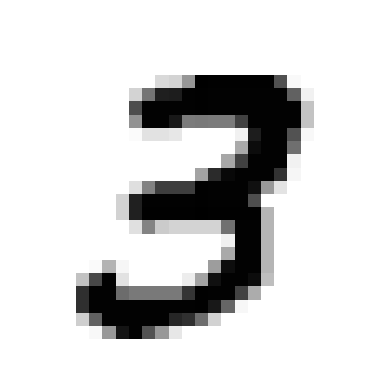

In [10]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    
    
some_digit = X_two[0]
plot_digit(some_digit)
plt.show()

## Training the LogisticRegression Model

In [11]:
from sklearn.linear_model import LogisticRegression

In [18]:
def sample_and_evaluate(X, y, K, test_size=200, seed=None):
    """
    Sample K examples per class for training (support set),
    sample test_size examples per class for testing, 
    train logistic regression, return acuracy and effective rank.
    """
    
    rng = np.random.default_rng(seed)
    
    #indices for each class
    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]
    
    #sample support set (K per class)
    train_0 = rng.choice(idx_0, size=K, replace=False)
    train_1 = rng.choice(idx_1, size=K, replace=False)
    
    #sample test set (test_size per class) from remaining
    rem_0 = np.setdiff1d(idx_0, train_0)
    rem_1 = np.setdiff1d(idx_1, train_1)
    
    test_0 = rng.choice(rem_0, size=test_size, replace=False)
    test_1 = rng.choice(rem_1, size=test_size, replace=False)
    
    #build sets
    X_train = np.vstack([X[train_0], X[train_1]])
    y_train = np.array([0]*K + [1]*K)
    
    X_test = np.vstack([X[test_0], X[test_1]])
    y_test = np.array([0]*test_size + [1]*test_size)
    
    #center training data (mean subtraction is critical for covariance)
    X_train_mean = X_train.mean(axis=0)
    X_train_centered = X_train - X_train_mean
    
    #train logistic regression (no regularization to see raw sample complexity)
    clf = LogisticRegression(max_iter=1000, C=np.inf)
    clf.fit(X_train_centered, y_train)
    
    #evaluate (center test with the same mean)
    X_test_centered = X_test - X_train_mean
    acc = clf.score(X_test_centered, y_test)
    
    #compute pooled within-class covariance
    cov_0 = np.cov(X_train_centered[:K], rowvar=False, bias=True)
    cov_1 = np.cov(X_train_centered[K:], rowvar=False, bias=True)
    cov_pooled = 0.5 * (cov_0 + cov_1)
    
    #compute effective rank
    eigvals = np.linalg.eigvalsh(cov_pooled)
    eigvals = np.maximum(eigvals, 1e-12)
    p = eigvals / eigvals.sum()
    erank = np.exp(-np.sum(p*np.log(p)))
    
    return acc, erank

In [19]:
K = 8
acc, erank = sample_and_evaluate(X_two, y_two, K=K, seed=42)
print(f"K={K}: accuracy={acc:.4f}, erank={erank:.2f}")

K=8: accuracy=0.8975, erank=11.35


## Full experiment loop.

In [20]:
results = []

for K in [2, 4, 8, 16, 32]:
    accs = []
    eranks = []
    for trial in range(50):
        acc, erank = sample_and_evaluate(X_two, y_two, K=K, seed=trial)
        accs.append(acc)
        eranks.append(erank)
    
    results.append({
        'K': K,
        'mean_acc': np.mean(accs),
        'std_acc': np.std(accs),
        'mean_erank': np.mean(eranks),
        'std_erank': np.std(eranks)
    })
    print(f"K={K:2d}: acc={np.mean(accs):.4f}±{np.std(accs):.4f}, erank={np.mean(eranks):.2f}±{np.std(eranks):.2f}")

# Convert to arrays for plotting
Ks = np.array([r['K'] for r in results])
mean_accs = np.array([r['mean_acc'] for r in results])
std_accs = np.array([r['std_acc'] for r in results])
mean_eranks = np.array([r['mean_erank'] for r in results])

K= 2: acc=0.7449±0.0717, erank=1.93±0.07
K= 4: acc=0.8170±0.0495, erank=5.44±0.16
K= 8: acc=0.8534±0.0365, erank=11.29±0.37
K=16: acc=0.8945±0.0208, erank=20.22±0.72
K=32: acc=0.9167±0.0176, erank=31.96±0.86


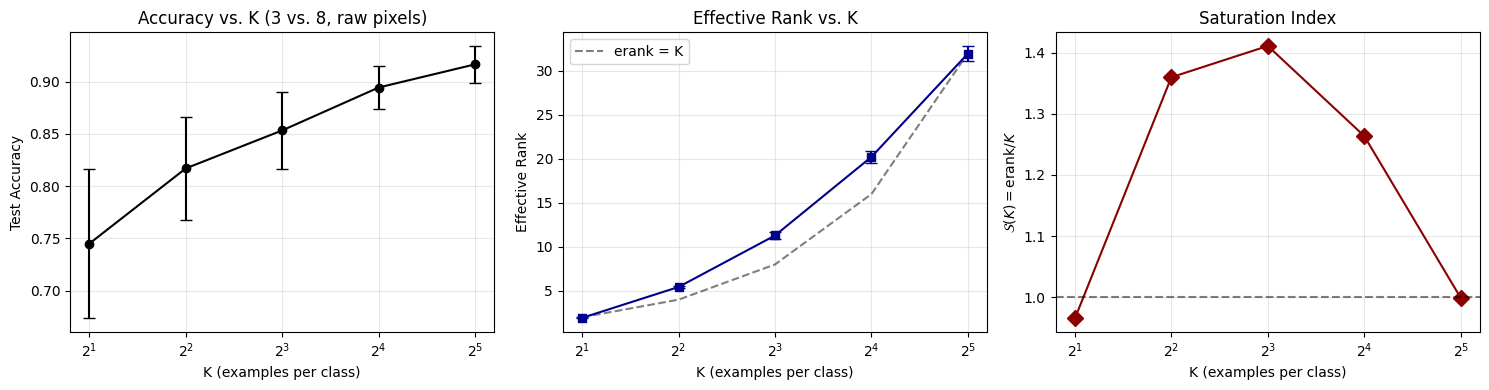

In [21]:
import matplotlib.pyplot as plt

# Data from your run
Ks = np.array([2, 4, 8, 16, 32])
mean_accs = np.array([0.7449, 0.8170, 0.8534, 0.8945, 0.9167])
std_accs = np.array([0.0717, 0.0495, 0.0365, 0.0208, 0.0176])
mean_eranks = np.array([1.93, 5.44, 11.29, 20.22, 31.96])
std_eranks = np.array([0.07, 0.16, 0.37, 0.72, 0.86])

saturation_index = mean_eranks / Ks

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Accuracy vs K (the classic saturation curve)
axes[0].errorbar(Ks, mean_accs, yerr=std_accs, fmt='o-', capsize=4, color='black')
axes[0].set_xlabel('K (examples per class)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Accuracy vs. K (3 vs. 8, raw pixels)')
axes[0].set_xscale('log', base=2)
axes[0].grid(True, alpha=0.3)

# Plot 2: Effective rank vs K
axes[1].errorbar(Ks, mean_eranks, yerr=std_eranks, fmt='s-', capsize=4, color='darkblue')
axes[1].plot(Ks, Ks, 'k--', alpha=0.5, label='erank = K')
axes[1].set_xlabel('K (examples per class)')
axes[1].set_ylabel('Effective Rank')
axes[1].set_title('Effective Rank vs. K')
axes[1].set_xscale('log', base=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: The saturation index
axes[2].plot(Ks, saturation_index, 'D-', color='darkred', markersize=8)
axes[2].axhline(y=1.0, color='k', linestyle='--', alpha=0.5)
axes[2].set_xlabel('K (examples per class)')
axes[2].set_ylabel(r'$\mathcal{S}(K) = \mathrm{erank} / K$')
axes[2].set_title('Saturation Index')
axes[2].set_xscale('log', base=2)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('saturation_raw_pixels.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
from sklearn.decomposition import PCA

# Fit PCA on the full two-class data
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_two)

results_pca = []

for K in [2, 4, 8, 16, 32, 64]:
    accs = []
    eranks = []
    for trial in range(50):
        acc, erank = sample_and_evaluate(X_pca, y_two, K=K, seed=trial)
        accs.append(acc)
        eranks.append(erank)
    
    results_pca.append({
        'K': K,
        'mean_acc': np.mean(accs),
        'std_acc': np.std(accs),
        'mean_erank': np.mean(eranks),
        'std_erank': np.std(eranks)
    })
    print(f"PCA K={K:2d}: acc={np.mean(accs):.4f}±{np.std(accs):.4f}, "
          f"erank={np.mean(eranks):.2f}±{np.std(eranks):.2f}, "
          f"S={np.mean(eranks)/K:.3f}")

PCA K= 2: acc=0.7486±0.0701, erank=1.91±0.09, S=0.955
PCA K= 4: acc=0.8166±0.0498, erank=5.24±0.22, S=1.310
PCA K= 8: acc=0.8491±0.0426, erank=10.28±0.45, S=1.285
PCA K=16: acc=0.8879±0.0268, erank=16.80±0.75, S=1.050
PCA K=32: acc=0.9081±0.0187, erank=23.05±0.69, S=0.720
PCA K=64: acc=0.9191±0.0203, erank=26.96±0.55, S=0.421


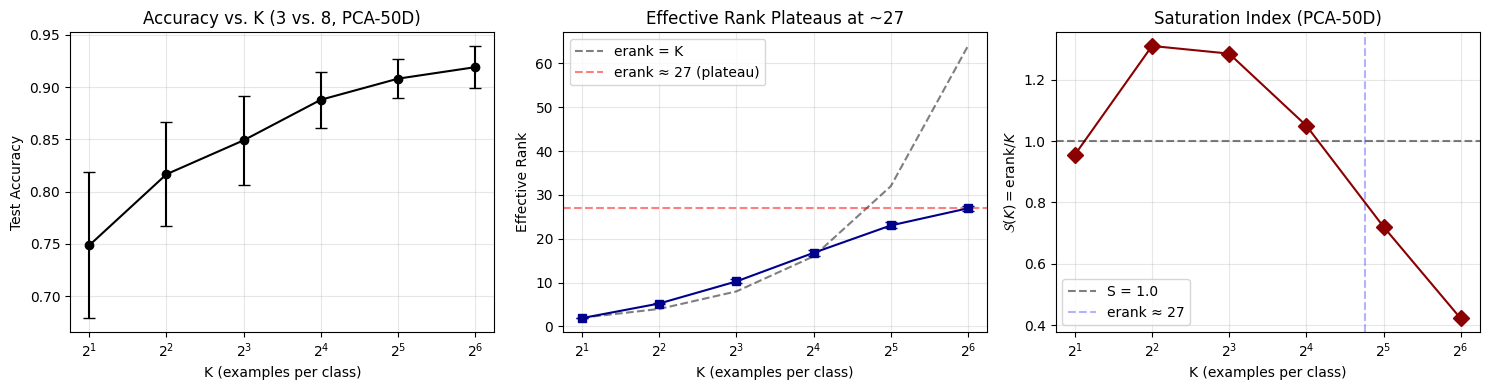

In [24]:
import matplotlib.pyplot as plt

Ks_pca = np.array([2, 4, 8, 16, 32, 64])
mean_accs_pca = np.array([0.7486, 0.8166, 0.8491, 0.8879, 0.9081, 0.9191])
std_accs_pca = np.array([0.0701, 0.0498, 0.0426, 0.0268, 0.0187, 0.0203])
mean_eranks_pca = np.array([1.91, 5.24, 10.28, 16.80, 23.05, 26.96])
std_eranks_pca = np.array([0.09, 0.22, 0.45, 0.75, 0.69, 0.55])
S_pca = mean_eranks_pca / Ks_pca

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Accuracy vs K (PCA)
axes[0].errorbar(Ks_pca, mean_accs_pca, yerr=std_accs_pca, fmt='o-', capsize=4, color='black')
axes[0].set_xlabel('K (examples per class)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Accuracy vs. K (3 vs. 8, PCA-50D)')
axes[0].set_xscale('log', base=2)
axes[0].grid(True, alpha=0.3)

# Plot 2: Effective rank vs K (showing plateau)
axes[1].errorbar(Ks_pca, mean_eranks_pca, yerr=std_eranks_pca, fmt='s-', capsize=4, color='darkblue')
axes[1].plot(Ks_pca, Ks_pca, 'k--', alpha=0.5, label='erank = K')
axes[1].axhline(y=27, color='red', linestyle='--', alpha=0.5, label='erank ≈ 27 (plateau)')
axes[1].set_xlabel('K (examples per class)')
axes[1].set_ylabel('Effective Rank')
axes[1].set_title('Effective Rank Plateaus at ~27')
axes[1].set_xscale('log', base=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Saturation index
axes[2].plot(Ks_pca, S_pca, 'D-', color='darkred', markersize=8)
axes[2].axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='S = 1.0')
axes[2].axvline(x=27, color='blue', linestyle='--', alpha=0.3, label='erank ≈ 27')
axes[2].set_xlabel('K (examples per class)')
axes[2].set_ylabel(r'$\mathcal{S}(K) = \mathrm{erank} / K$')
axes[2].set_title('Saturation Index (PCA-50D)')
axes[2].set_xscale('log', base=2)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('saturation_pca_50d.png', dpi=150, bbox_inches='tight')
plt.show()

K extended to 512

In [25]:
Ks_full = [2, 4, 8, 16, 32, 64, 128, 256, 512]

results_38_full = []

for K in Ks_full:
    accs, eranks = [], []
    for trial in range(50):
        acc, erank = sample_and_evaluate(X_pca, y_two, K=K, seed=trial)
        accs.append(acc)
        eranks.append(erank)
    
    results_38_full.append({
        'K': K,
        'mean_acc': np.mean(accs),
        'std_acc': np.std(accs),
        'mean_erank': np.mean(eranks),
        'S': np.mean(eranks) / K
    })
    print(f"3v8 K={K:3d}: acc={np.mean(accs):.4f}±{np.std(accs):.4f}, "
          f"erank={np.mean(eranks):.2f}, S={np.mean(eranks)/K:.3f}")

3v8 K=  2: acc=0.7486±0.0701, erank=1.91, S=0.955
3v8 K=  4: acc=0.8166±0.0498, erank=5.24, S=1.310
3v8 K=  8: acc=0.8491±0.0426, erank=10.28, S=1.285
3v8 K= 16: acc=0.8879±0.0268, erank=16.80, S=1.050
3v8 K= 32: acc=0.9081±0.0187, erank=23.05, S=0.720
3v8 K= 64: acc=0.9191±0.0203, erank=26.96, S=0.421
3v8 K=128: acc=0.9284±0.0151, erank=29.31, S=0.229
3v8 K=256: acc=0.9248±0.0223, erank=30.44, S=0.119
3v8 K=512: acc=0.9501±0.0103, erank=31.01, S=0.061


In [26]:
def run_pair(class_a, class_b, Ks=[2, 4, 8, 16, 32, 64], n_trials=50):
    mask = (y == class_a) | (y == class_b)
    X_pair = X[mask]
    y_pair = y[mask]
    y_pair = np.where(y_pair == class_a, 0, 1)
    
    # PCA fit on THIS pair's data (critical: do not reuse 3v8 PCA)
    pca = PCA(n_components=50)
    X_pca = pca.fit_transform(X_pair)
    
    results = []
    for K in Ks:
        accs, eranks = [], []
        for trial in range(n_trials):
            acc, erank = sample_and_evaluate(X_pca, y_pair, K=K, seed=trial)
            accs.append(acc)
            eranks.append(erank)
        results.append({
            'K': K,
            'mean_acc': np.mean(accs),
            'std_acc': np.std(accs),
            'mean_erank': np.mean(eranks),
            'S': np.mean(eranks) / K
        })
        print(f"{class_a}v{class_b} K={K:2d}: acc={np.mean(accs):.4f}, erank={np.mean(eranks):.2f}, S={np.mean(eranks)/K:.3f}")
    return results

# Run the three pairs
results_01 = run_pair(0, 1, Ks=[2, 4, 8, 16, 32, 64])
results_38 = run_pair(3, 8, Ks=[2, 4, 8, 16, 32, 64])
results_49 = run_pair(4, 9, Ks=[2, 4, 8, 16, 32, 64])

0v1 K= 2: acc=0.9484, erank=1.79, S=0.896
0v1 K= 4: acc=0.9762, erank=4.48, S=1.121
0v1 K= 8: acc=0.9888, erank=8.71, S=1.089
0v1 K=16: acc=0.9932, erank=13.49, S=0.843
0v1 K=32: acc=0.9951, erank=18.34, S=0.573
0v1 K=64: acc=0.9977, erank=21.10, S=0.330
3v8 K= 2: acc=0.7486, erank=1.91, S=0.955
3v8 K= 4: acc=0.8166, erank=5.24, S=1.310
3v8 K= 8: acc=0.8491, erank=10.28, S=1.285
3v8 K=16: acc=0.8879, erank=16.80, S=1.050
3v8 K=32: acc=0.9081, erank=23.05, S=0.720
3v8 K=64: acc=0.9191, erank=26.96, S=0.421
4v9 K= 2: acc=0.6273, erank=1.90, S=0.951
4v9 K= 4: acc=0.7127, erank=4.98, S=1.245
4v9 K= 8: acc=0.7844, erank=9.81, S=1.227
4v9 K=16: acc=0.8631, erank=15.32, S=0.958
4v9 K=32: acc=0.8986, erank=20.29, S=0.634
4v9 K=64: acc=0.9225, erank=23.62, S=0.369


In [27]:
# Extended sweep for 3 vs. 8 up to data limit
Ks_extended = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

results_38_extended = []

for K in Ks_extended:
    accs, eranks = [], []
    for trial in range(20):  # 20 trials is enough at large K (very low variance)
        acc, erank = sample_and_evaluate(X_pca, y_two, K=K, seed=trial)
        accs.append(acc)
        eranks.append(erank)
    
    results_38_extended.append({
        'K': K,
        'mean_acc': np.mean(accs),
        'std_acc': np.std(accs),
        'mean_erank': np.mean(eranks),
        'S': np.mean(eranks) / K
    })
    print(f"3v8 K={K:4d}: acc={np.mean(accs):.4f}±{np.std(accs):.4f}, "
          f"erank={np.mean(eranks):.2f}, S={np.mean(eranks)/K:.4f}, "
          f"marginal_vs_prev={np.mean(accs) - results_38_extended[-2]['mean_acc'] if len(results_38_extended)>1 else 0:+.4f}")

# Also extend 0v1 and 4v9 to K=1024 or 2048 to see their asymptotes
# 0v1 will likely saturate much earlier (erank ceiling ~25-30)
# 4v9 may have a higher ceiling than 3v8 (more visually similar = needs more dimensions)

3v8 K=   2: acc=0.7345±0.0708, erank=1.92, S=0.9578, marginal_vs_prev=+0.0000
3v8 K=   4: acc=0.7944±0.0561, erank=5.21, S=1.3036, marginal_vs_prev=+0.0599
3v8 K=   8: acc=0.8504±0.0322, erank=10.37, S=1.2956, marginal_vs_prev=+0.0560
3v8 K=  16: acc=0.8846±0.0262, erank=16.78, S=1.0489, marginal_vs_prev=+0.0343
3v8 K=  32: acc=0.9118±0.0187, erank=23.09, S=0.7215, marginal_vs_prev=+0.0271
3v8 K=  64: acc=0.9178±0.0199, erank=27.03, S=0.4224, marginal_vs_prev=+0.0060
3v8 K= 128: acc=0.9277±0.0107, erank=29.35, S=0.2293, marginal_vs_prev=+0.0100
3v8 K= 256: acc=0.9271±0.0200, erank=30.40, S=0.1188, marginal_vs_prev=-0.0006
3v8 K= 512: acc=0.9498±0.0124, erank=30.98, S=0.0605, marginal_vs_prev=+0.0226
3v8 K=1024: acc=0.9591±0.0104, erank=31.36, S=0.0306, marginal_vs_prev=+0.0094
3v8 K=2048: acc=0.9677±0.0080, erank=31.47, S=0.0154, marginal_vs_prev=+0.0086
3v8 K=4096: acc=0.9597±0.0109, erank=31.56, S=0.0077, marginal_vs_prev=-0.0080


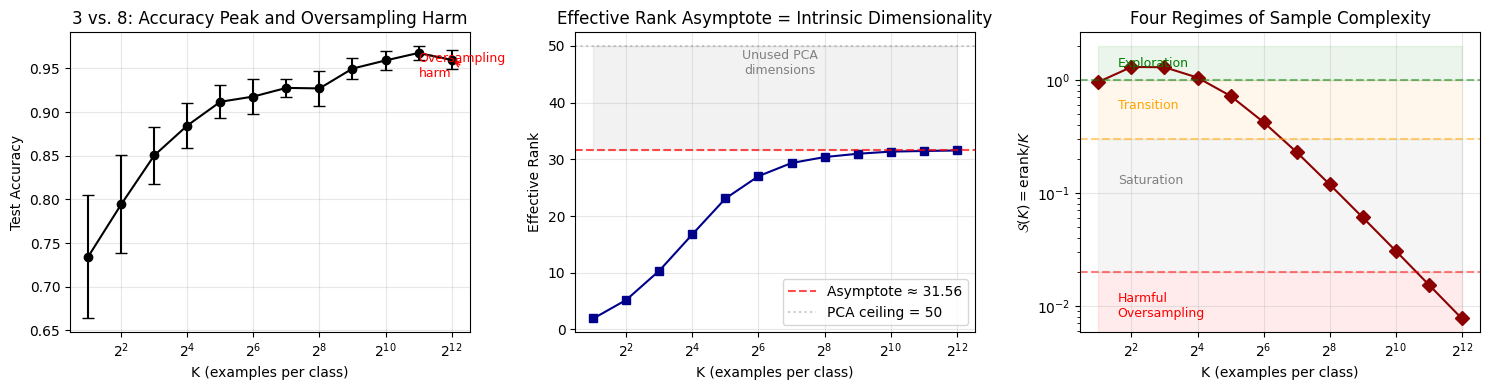

In [28]:
import matplotlib.pyplot as plt
import numpy as np

Ks_ext = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096])
accs_ext = np.array([0.7345, 0.7944, 0.8504, 0.8846, 0.9118, 0.9178, 
                     0.9277, 0.9271, 0.9498, 0.9591, 0.9677, 0.9597])
stds_ext = np.array([0.0708, 0.0561, 0.0322, 0.0262, 0.0187, 0.0199,
                     0.0107, 0.0200, 0.0124, 0.0104, 0.0080, 0.0109])
eranks_ext = np.array([1.92, 5.21, 10.37, 16.78, 23.09, 27.03, 
                       29.35, 30.40, 30.98, 31.36, 31.47, 31.56])
S_ext = eranks_ext / Ks_ext

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel A: Accuracy with the DROP highlighted
axes[0].errorbar(Ks_ext, accs_ext, yerr=stds_ext, fmt='o-', capsize=4, color='black')
axes[0].plot([2048, 4096], [0.9677, 0.9597], 'r--', alpha=0.5)  # highlight drop
axes[0].annotate('Oversampling\nharm', xy=(4096, 0.9597), xytext=(2048, 0.94),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')
axes[0].set_xlabel('K (examples per class)')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('3 vs. 8: Accuracy Peak and Oversampling Harm')
axes[0].set_xscale('log', base=2)
axes[0].grid(True, alpha=0.3)

# Panel B: erank asymptote to ~31.5
axes[1].plot(Ks_ext, eranks_ext, 's-', color='darkblue', markersize=6)
axes[1].axhline(y=31.56, color='red', linestyle='--', alpha=0.7, label='Asymptote ≈ 31.56')
axes[1].axhline(y=50, color='gray', linestyle=':', alpha=0.4, label='PCA ceiling = 50')
axes[1].fill_between(Ks_ext, 31.56, 50, alpha=0.1, color='gray')
axes[1].text(100, 45, 'Unused PCA\ndimensions', fontsize=9, color='gray', ha='center')
axes[1].set_xlabel('K (examples per class)')
axes[1].set_ylabel('Effective Rank')
axes[1].set_title('Effective Rank Asymptote = Intrinsic Dimensionality')
axes[1].set_xscale('log', base=2)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel C: Phase diagram with all four regimes
axes[2].plot(Ks_ext, S_ext, 'D-', color='darkred', markersize=7)
axes[2].axhline(y=1.0, color='green', linestyle='--', alpha=0.5)
axes[2].axhline(y=0.3, color='orange', linestyle='--', alpha=0.5)
axes[2].axhline(y=0.02, color='red', linestyle='--', alpha=0.5)
axes[2].fill_between([2, 4096], 1.0, 2.0, alpha=0.08, color='green')
axes[2].fill_between([2, 4096], 0.3, 1.0, alpha=0.08, color='orange')
axes[2].fill_between([2, 4096], 0.02, 0.3, alpha=0.08, color='gray')
axes[2].fill_between([2, 4096], 0.0, 0.02, alpha=0.08, color='red')
axes[2].text(3, 1.3, 'Exploration', fontsize=9, color='green')
axes[2].text(3, 0.55, 'Transition', fontsize=9, color='orange')
axes[2].text(3, 0.12, 'Saturation', fontsize=9, color='gray')
axes[2].text(3, 0.008, 'Harmful\nOversampling', fontsize=9, color='red')
axes[2].set_xlabel('K (examples per class)')
axes[2].set_ylabel(r'$\mathcal{S}(K) = \mathrm{erank} / K$')
axes[2].set_title('Four Regimes of Sample Complexity')
axes[2].set_xscale('log', base=2)
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure3_asymptote_and_phases.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Verify the K=4096 drop is not a test-size artifact
acc_bigtest, erank_bigtest = sample_and_evaluate(X_pca, y_two, K=4096, test_size=1000, seed=999)
print(f"K=4096, test_size=1000: acc={acc_bigtest:.4f}, erank={erank_bigtest:.2f}")

K=4096, test_size=1000: acc=0.9590, erank=31.53


In [30]:
def run_extended_pair(class_a, class_b, Ks=[2,4,8,16,32,64,128,256,512,1024,2048,4096], n_trials=20):
    mask = (y == class_a) | (y == class_b)
    X_pair = X[mask]
    y_pair = y[mask]
    y_pair = np.where(y_pair == class_a, 0, 1)
    
    # PCA fit on THIS pair's data
    pca = PCA(n_components=50)
    X_pca = pca.fit_transform(X_pair)
    
    results = []
    for K in Ks:
        accs, eranks = [], []
        for trial in range(n_trials):
            acc, erank = sample_and_evaluate(X_pca, y_pair, K=K, seed=trial)
            accs.append(acc)
            eranks.append(erank)
        
        mean_acc = np.mean(accs)
        prev_acc = results[-1]['mean_acc'] if results else mean_acc
        marginal = mean_acc - prev_acc
        
        results.append({
            'K': K,
            'mean_acc': mean_acc,
            'std_acc': np.std(accs),
            'mean_erank': np.mean(eranks),
            'S': np.mean(eranks) / K,
            'marginal': marginal
        })
        print(f"{class_a}v{class_b} K={K:4d}: acc={mean_acc:.4f}±{np.std(accs):.4f}, "
              f"erank={np.mean(eranks):.2f}, S={np.mean(eranks)/K:.4f}, marginal={marginal:+.4f}")
    return results

# Run both extended sweeps
print("="*60)
print("0 vs. 1 (easy pair)")
print("="*60)
results_01_ext = run_extended_pair(0, 1)

print("\n" + "="*60)
print("4 vs. 9 (hard pair)")
print("="*60)
results_49_ext = run_extended_pair(4, 9)

0 vs. 1 (easy pair)
0v1 K=   2: acc=0.9440±0.0411, erank=1.78, S=0.8886, marginal=+0.0000
0v1 K=   4: acc=0.9830±0.0158, erank=4.43, S=1.1069, marginal=+0.0390
0v1 K=   8: acc=0.9874±0.0110, erank=8.70, S=1.0873, marginal=+0.0044
0v1 K=  16: acc=0.9920±0.0048, erank=13.32, S=0.8323, marginal=+0.0046
0v1 K=  32: acc=0.9942±0.0039, erank=18.49, S=0.5780, marginal=+0.0022
0v1 K=  64: acc=0.9969±0.0032, erank=21.01, S=0.3283, marginal=+0.0026
0v1 K= 128: acc=0.9970±0.0026, erank=22.95, S=0.1793, marginal=+0.0001
0v1 K= 256: acc=0.9975±0.0022, erank=23.75, S=0.0928, marginal=+0.0005
0v1 K= 512: acc=0.9992±0.0011, erank=24.13, S=0.0471, marginal=+0.0017
0v1 K=1024: acc=0.9986±0.0018, erank=24.42, S=0.0238, marginal=-0.0006
0v1 K=2048: acc=0.9990±0.0012, erank=24.51, S=0.0120, marginal=+0.0004
0v1 K=4096: acc=0.9977±0.0025, erank=24.56, S=0.0060, marginal=-0.0012

4 vs. 9 (hard pair)
4v9 K=   2: acc=0.6185±0.0623, erank=1.89, S=0.9447, marginal=+0.0000
4v9 K=   4: acc=0.6966±0.0726, erank=5.0

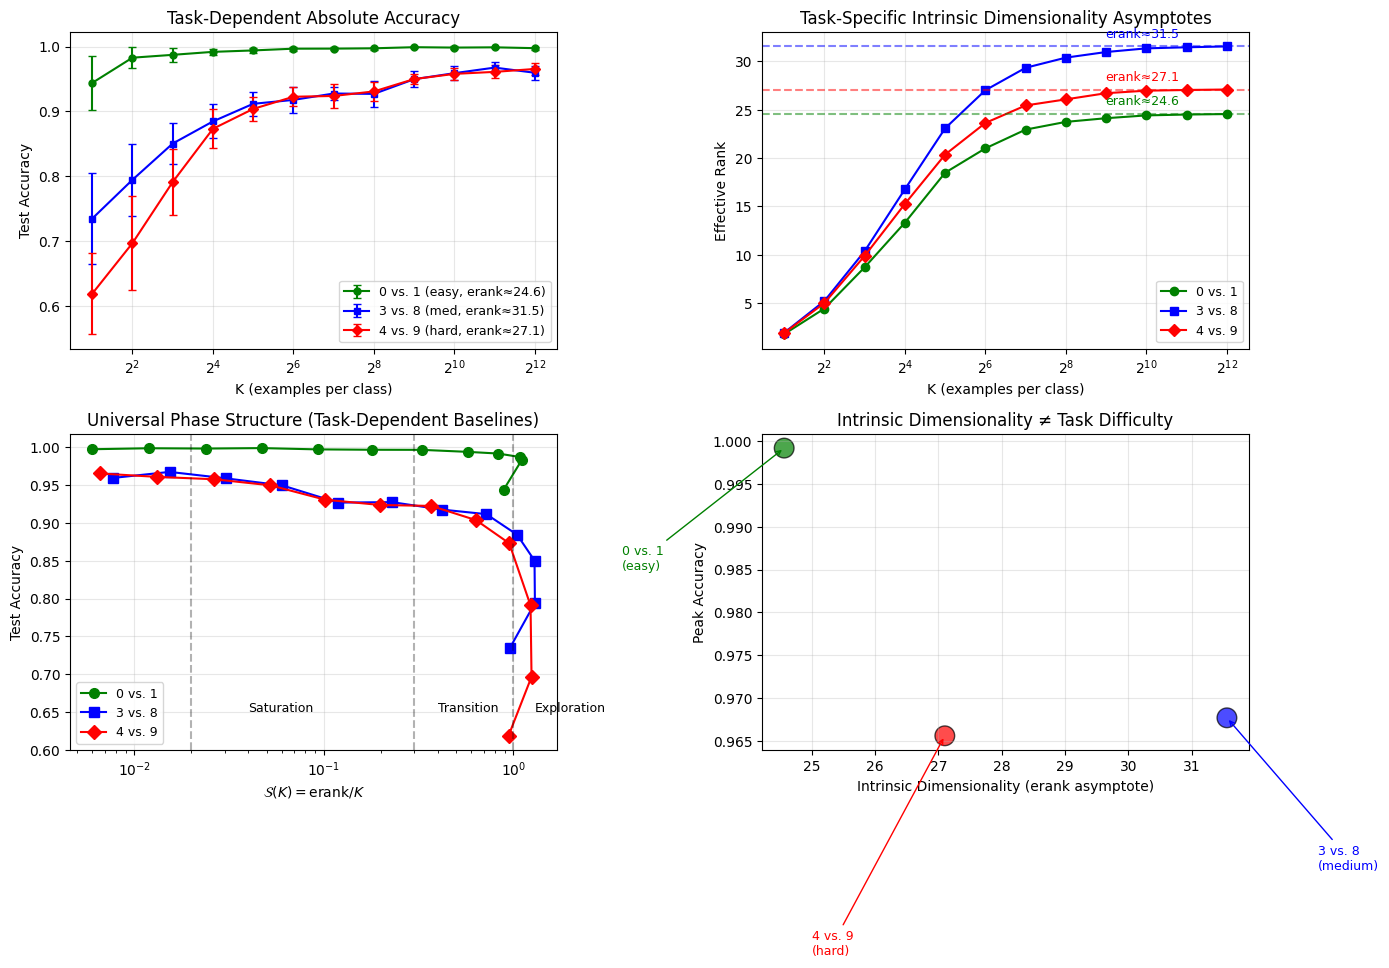

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Data
Ks = np.array([2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096])

# 0v1
accs_01 = np.array([0.9440, 0.9830, 0.9874, 0.9920, 0.9942, 0.9969, 0.9970, 0.9975, 0.9992, 0.9986, 0.9990, 0.9977])
stds_01 = np.array([0.0411, 0.0158, 0.0110, 0.0048, 0.0039, 0.0032, 0.0026, 0.0022, 0.0011, 0.0018, 0.0012, 0.0025])
eranks_01 = np.array([1.78, 4.43, 8.70, 13.32, 18.49, 21.01, 22.95, 23.75, 24.13, 24.42, 24.51, 24.56])
S_01 = eranks_01 / Ks

# 3v8
accs_38 = np.array([0.7345, 0.7944, 0.8504, 0.8846, 0.9118, 0.9178, 0.9277, 0.9271, 0.9498, 0.9591, 0.9677, 0.9597])
stds_38 = np.array([0.0708, 0.0561, 0.0322, 0.0262, 0.0187, 0.0199, 0.0107, 0.0200, 0.0124, 0.0104, 0.0080, 0.0109])
eranks_38 = np.array([1.92, 5.21, 10.37, 16.78, 23.09, 27.03, 29.35, 30.40, 30.98, 31.36, 31.47, 31.56])
S_38 = eranks_38 / Ks

# 4v9
accs_49 = np.array([0.6185, 0.6966, 0.7910, 0.8732, 0.9039, 0.9227, 0.9239, 0.9309, 0.9500, 0.9580, 0.9611, 0.9656])
stds_49 = np.array([0.0623, 0.0726, 0.0516, 0.0303, 0.0185, 0.0149, 0.0187, 0.0152, 0.0080, 0.0090, 0.0101, 0.0093])
eranks_49 = np.array([1.89, 5.00, 9.88, 15.26, 20.37, 23.64, 25.45, 26.08, 26.72, 26.98, 27.05, 27.10])
S_49 = eranks_49 / Ks

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Accuracy vs K (three curves, showing task-dependent difficulty)
axes[0,0].errorbar(Ks, accs_01, yerr=stds_01, fmt='o-', capsize=3, color='green', label='0 vs. 1 (easy, erank≈24.6)', markersize=5)
axes[0,0].errorbar(Ks, accs_38, yerr=stds_38, fmt='s-', capsize=3, color='blue', label='3 vs. 8 (med, erank≈31.5)', markersize=5)
axes[0,0].errorbar(Ks, accs_49, yerr=stds_49, fmt='D-', capsize=3, color='red', label='4 vs. 9 (hard, erank≈27.1)', markersize=5)
axes[0,0].set_xlabel('K (examples per class)')
axes[0,0].set_ylabel('Test Accuracy')
axes[0,0].set_title('Task-Dependent Absolute Accuracy')
axes[0,0].set_xscale('log', base=2)
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3)

# Top-right: erank asymptotes (THE KEY FIGURE)
axes[0,1].plot(Ks, eranks_01, 'o-', color='green', label='0 vs. 1')
axes[0,1].plot(Ks, eranks_38, 's-', color='blue', label='3 vs. 8')
axes[0,1].plot(Ks, eranks_49, 'D-', color='red', label='4 vs. 9')
axes[0,1].axhline(y=24.56, color='green', linestyle='--', alpha=0.5)
axes[0,1].axhline(y=31.56, color='blue', linestyle='--', alpha=0.5)
axes[0,1].axhline(y=27.10, color='red', linestyle='--', alpha=0.5)
axes[0,1].text(500, 25.5, 'erank≈24.6', fontsize=9, color='green')
axes[0,1].text(500, 32.5, 'erank≈31.5', fontsize=9, color='blue')
axes[0,1].text(500, 28.0, 'erank≈27.1', fontsize=9, color='red')
axes[0,1].set_xlabel('K (examples per class)')
axes[0,1].set_ylabel('Effective Rank')
axes[0,1].set_title('Task-Specific Intrinsic Dimensionality Asymptotes')
axes[0,1].set_xscale('log', base=2)
axes[0,1].legend(fontsize=9)
axes[0,1].grid(True, alpha=0.3)

# Bottom-left: Phase alignment on S(K) = erank/K
axes[1,0].plot(S_01, accs_01, 'o-', color='green', label='0 vs. 1', markersize=7)
axes[1,0].plot(S_38, accs_38, 's-', color='blue', label='3 vs. 8', markersize=7)
axes[1,0].plot(S_49, accs_49, 'D-', color='red', label='4 vs. 9', markersize=7)
axes[1,0].axvline(x=1.0, color='black', linestyle='--', alpha=0.3)
axes[1,0].axvline(x=0.3, color='black', linestyle='--', alpha=0.3)
axes[1,0].axvline(x=0.02, color='black', linestyle='--', alpha=0.3)
axes[1,0].text(1.3, 0.65, 'Exploration', fontsize=9)
axes[1,0].text(0.4, 0.65, 'Transition', fontsize=9)
axes[1,0].text(0.04, 0.65, 'Saturation', fontsize=9)
axes[1,0].set_xlabel(r'$\mathcal{S}(K) = \mathrm{erank} / K$')
axes[1,0].set_ylabel('Test Accuracy')
axes[1,0].set_title('Universal Phase Structure (Task-Dependent Baselines)')
axes[1,0].set_xscale('log')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(True, alpha=0.3)

# Bottom-right: The decoupling insight
# Scatter: erank asymptote vs. peak accuracy
axes[1,1].scatter([24.56, 31.56, 27.10], [0.9992, 0.9677, 0.9656], 
                   s=200, c=['green', 'blue', 'red'], alpha=0.7, edgecolors='black')
axes[1,1].annotate('0 vs. 1\n(easy)', xy=(24.56, 0.9992), xytext=(22, 0.985),
                   fontsize=9, color='green',
                   arrowprops=dict(arrowstyle='->', color='green'))
axes[1,1].annotate('3 vs. 8\n(medium)', xy=(31.56, 0.9677), xytext=(33, 0.95),
                   fontsize=9, color='blue',
                   arrowprops=dict(arrowstyle='->', color='blue'))
axes[1,1].annotate('4 vs. 9\n(hard)', xy=(27.10, 0.9656), xytext=(25, 0.94),
                   fontsize=9, color='red',
                   arrowprops=dict(arrowstyle='->', color='red'))
axes[1,1].set_xlabel('Intrinsic Dimensionality (erank asymptote)')
axes[1,1].set_ylabel('Peak Accuracy')
axes[1,1].set_title('Intrinsic Dimensionality ≠ Task Difficulty')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure4_multi_task_full.png', dpi=150, bbox_inches='tight')
plt.show()